# Sistemas de Recomendação de Filmes

Este notebook implementa dois modelos de recomendação utilizando o arquivo `movies_3.csv`:
1. **Best Seller (Recomendação Populares / Por Gênero)**
2. **Recomendação por Similaridade (Filtragem Baseada em Conteúdo com TF-IDF e Similaridade de Cosseno)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Carregar os dados (Ajuste o nome do arquivo se necessário)
df = pd.read_csv('movies.csv')

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
# Extrair o ano de lançamento a partir do título (ex: 'Toy Story (1995)' -> 1995)
df['year'] = df['title'].str.extract(r'\((\d{4})\)$').astype(float)

df.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0


## 1. Sistema Best Seller (Mais Vendidos / Populares por Gênero)

O sistema **Best Seller** oferece recomendações globais ou filtradas por categoria e ano de lançamento para novos usuários (*Cold Start*).

In [3]:
def obter_best_sellers(df, genero=None, top_n=5, ano_minimo=None):
    """
    Retorna os filmes de maior destaque no catálogo,
    com opção de filtro por gênero e ano de lançamento.
    """
    resultado = df.copy()

    if genero:
        resultado = resultado[resultado['genres'].str.contains(genero, case=False, na=False)]

    if ano_minimo:
        resultado = resultado[resultado['year'] >= ano_minimo]

    cols = ['movieId', 'title', 'genres', 'year']
    return resultado[cols].head(top_n)

# Exemplo de Teste: Top 5 Filmes de Ação a partir de 2015
print("=== BEST SELLERS: Ação (A partir de 2015) ===")
obter_best_sellers(df, genero='Action', top_n=5, ano_minimo=2015)

=== BEST SELLERS: Ação (A partir de 2015) ===


,movieId,title,genres,year
8439,111781,Mission: Impossible - Rogue Nation (2015),Action|Adventure|Thriller,2015.0
8489,113345,Jupiter Ascending (2015),Action|Adventure|Sci-Fi,2015.0
8588,117466,In the Heart of the Sea (2015),Action|Adventure|Drama,2015.0
8590,117529,Jurassic World (2015),Action|Adventure|Drama|Sci-Fi|Thriller,2015.0
8604,117895,Maze Runner: Scorch Trials (2015),Action|Thriller,2015.0


## 2. Sistema de Recomendação por Similaridade (Content-Based)

Utiliza **TF-IDF** para vetorizar os gêneros dos filmes e **Similaridade de Cosseno** para encontrar filmes com o perfil idêntico ou próximo ao pesquisado.

In [4]:
# Tratar a coluna de gêneros (substituir '|' por espaço para vetorização)
df['genres_clean'] = df['genres'].str.replace('|', ' ', regex=False)

# Criar a matriz TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['genres_clean'])

# Calcular a matriz de Similaridade de Cosseno
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recomendar_por_similaridade(titulo, df=df, cosine_sim=cosine_sim, top_n=5):
    """
    Recebe o nome de um filme e retorna os N filmes mais parecidos com base no gênero.
    """
    matches = df[df['title'].str.contains(titulo, case=False, na=False)]

    if matches.empty:
        print(f"Filme '{titulo}' não encontrado no catálogo.")
        return None

    idx = matches.index[0]
    titulo_encontrado = df.loc[idx, 'title']

    # Calcular pontuações de similaridade
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Filtrar o próprio filme (índice 0) e pegar os N mais similares
    sim_scores = sim_scores[1:top_n+1]

    indices_recomendados = [i[0] for i in sim_scores]

    res = df[['movieId', 'title', 'genres']].iloc[indices_recomendados].copy()
    res['score_similaridade'] = [round(i[1], 2) for i in sim_scores]

    print(f"=== Recomendações para: '{titulo_encontrado}' ===")
    return res

# Exemplo de Teste:
recomendar_por_similaridade('Toy Story', top_n=5)

=== Recomendações para: 'Toy Story (1995)' ===


,movieId,title,genres,score_similaridade
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0


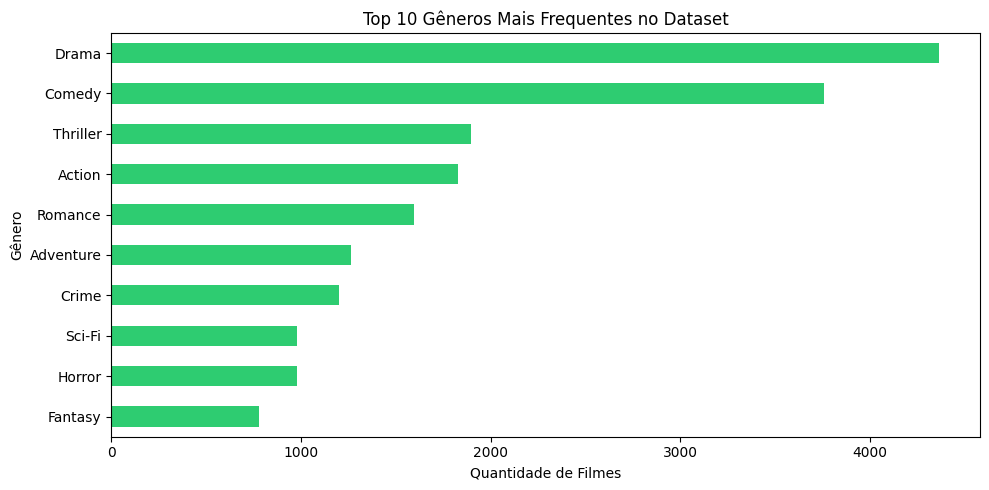

In [5]:
# Análise Gráfica dos Gêneros mais Frequentes
df_genres = df['genres'].str.split('|', expand=True).stack().value_counts()

plt.figure(figsize=(10, 5))
df_genres.head(10).plot(kind='barh', color='#2ecc71')
plt.title('Top 10 Gêneros Mais Frequentes no Dataset')
plt.xlabel('Quantidade de Filmes')
plt.ylabel('Gênero')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()